<a href="https://colab.research.google.com/github/silviyax03/Content-Monetization-Modeler/blob/main/Content_Monetization_Modeler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('/content/youtube_ad_revenue_dataset.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print("Shape of dataset:", df.shape)

Shape of dataset: (122400, 12)


In [4]:
df.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [5]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'category', 'device', 'country', 'ad_revenue_usd']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  object 
 1   date                  122400 non-null  object 
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  object 
 9   device                122400 non-null  object 
 10  country               122400 non-null  object 
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 11.2+ MB


In [7]:
missing_values = df.isnull().sum()
print(missing_values)

video_id                   0
date                       0
views                      0
likes                   6117
comments                6112
watch_time_minutes      6105
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64


In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.sort_values(ascending=False))

likes                   4.997549
comments                4.993464
watch_time_minutes      4.987745
video_id                0.000000
views                   0.000000
date                    0.000000
video_length_minutes    0.000000
subscribers             0.000000
category                0.000000
device                  0.000000
country                 0.000000
ad_revenue_usd          0.000000
dtype: float64


In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 2400


In [10]:
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [11]:
df_clean = df.copy()
print("Original shape:", df_clean.shape)

Original shape: (122400, 12)


In [12]:
print(df_clean['date'].dtype)

object


In [13]:
#Convert date to datetime
df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')

print(df_clean['date'].dtype)

datetime64[ns]


In [14]:
print("Invalid dates:", df_clean['date'].isnull().sum())

Invalid dates: 0


In [15]:
#Remove Duplicates
df_clean = df_clean.drop_duplicates()
print("Shape after removing duplicates:", df_clean.shape)
print("Remaining duplicates:", df_clean.duplicated().sum())

Shape after removing duplicates: (120000, 12)
Remaining duplicates: 0


In [16]:
#Handle missing numerical values
numeric_columns = [
    'likes',
    'comments',
    'watch_time_minutes'
]

for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [17]:
print(df_clean.isnull().sum())
print("Total missing values:", df_clean.isnull().sum().sum())
print("Final shape:", df_clean.shape)

video_id                0
date                    0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
dtype: int64
Total missing values: 0
Final shape: (120000, 12)


In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   video_id              120000 non-null  object        
 1   date                  120000 non-null  datetime64[ns]
 2   views                 120000 non-null  int64         
 3   likes                 120000 non-null  float64       
 4   comments              120000 non-null  float64       
 5   watch_time_minutes    120000 non-null  float64       
 6   video_length_minutes  120000 non-null  float64       
 7   subscribers           120000 non-null  int64         
 8   category              120000 non-null  object        
 9   device                120000 non-null  object        
 10  country               120000 non-null  object        
 11  ad_revenue_usd        120000 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(2), object(4)
memory us

In [19]:
df_clean.to_csv(
    '/content/youtube_monetization_cleaned.csv',
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [20]:
df_clean.describe()

,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,120000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000,120000.000000
mean,2024-12-08 03:24:11.233198848,9999.832333,1099.705792,274.332350,37539.823485,16.017910,502291.970050,252.711361
min,2024-06-09 10:50:40.993199,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,2024-09-07 10:50:40.993199104,9933.000000,673.000000,168.000000,26949.914101,9.005928,252641.500000,199.892158
50%,2024-12-08 10:50:40.993199104,10000.000000,1102.000000,274.000000,37522.221205,16.009269,503633.500000,252.678607
75%,2025-03-09 10:50:40.993199104,10067.000000,1524.000000,381.000000,48209.880123,23.026064,752386.250000,305.613497
max,2025-06-08 10:50:40.993199,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254
std,NaN,99.918405,506.372185,126.461529,12658.957710,8.084928,288364.967705,61.954125


In [21]:
df_clean.select_dtypes(include=np.number).skew().sort_values(ascending=False)

,0
comments,0.008859
watch_time_minutes,0.001790
ad_revenue_usd,0.000948
video_length_minutes,-0.001861
views,-0.002912
likes,-0.002975
subscribers,-0.009575


In [22]:
categorical_columns = ['category', 'device', 'country']

for col in categorical_columns:
    print("\n" + "=" * 50)
    print(f"Column: {col}")
    print("=" * 50)

    print("Number of unique values:", df_clean[col].nunique())
    print("\nValue counts:")
    print(df_clean[col].value_counts())


Column: category
Number of unique values: 6

Value counts:
category
Education        20123
Music            20065
Tech             20028
Entertainment    20025
Gaming           19974
Lifestyle        19785
Name: count, dtype: int64

Column: device
Number of unique values: 4

Value counts:
device
TV         30086
Mobile     29989
Desktop    29984
Tablet     29941
Name: count, dtype: int64

Column: country
Number of unique values: 6

Value counts:
country
CA    20198
DE    20160
IN    20156
AU    19911
UK    19893
US    19682
Name: count, dtype: int64


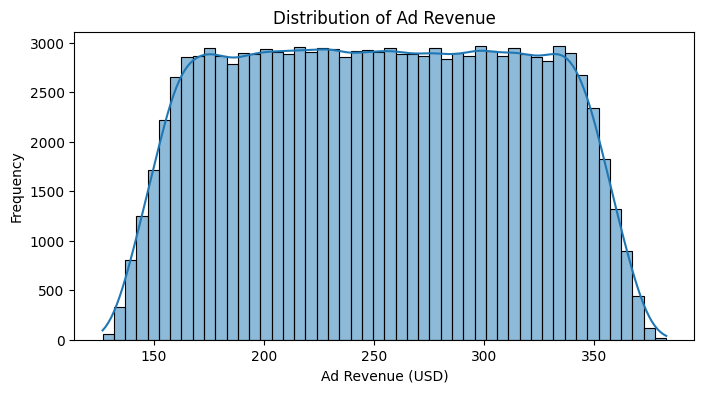

In [23]:
#Analyze the Target Variable
plt.figure(figsize=(8, 4))

sns.histplot(
    df_clean['ad_revenue_usd'],
    bins=50,
    kde=True
)

plt.title('Distribution of Ad Revenue')
plt.xlabel('Ad Revenue (USD)')
plt.ylabel('Frequency')

plt.show()

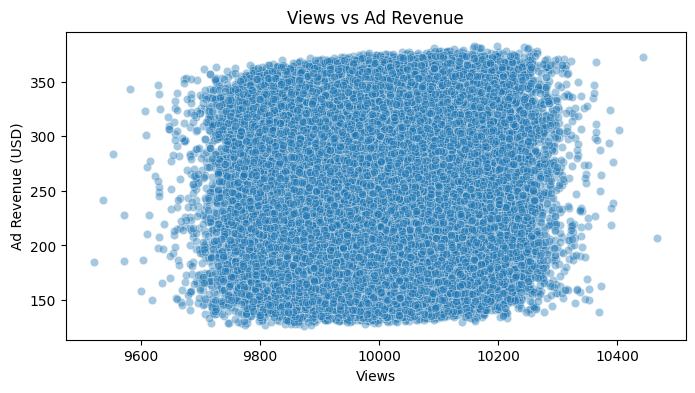

In [24]:
#Views vs Ad Revenue: check whether views are related to ad revenue
plt.figure(figsize=(8, 4))

sns.scatterplot(
    data=df_clean,
    x='views',
    y='ad_revenue_usd',
    alpha=0.4
)

plt.title('Views vs Ad Revenue')
plt.xlabel('Views')
plt.ylabel('Ad Revenue (USD)')

plt.show()

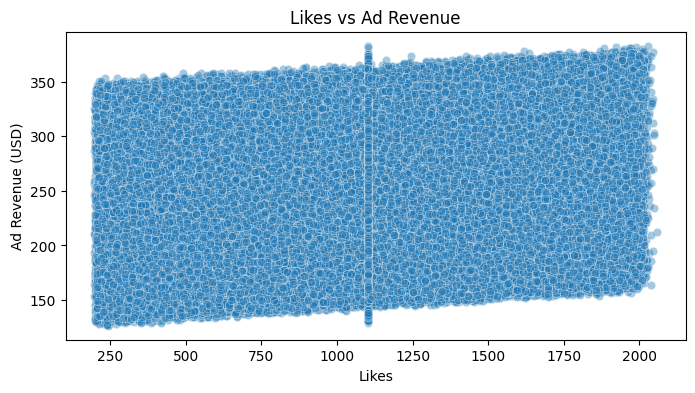

In [25]:
#Likes vs Ad Revenue
plt.figure(figsize=(8, 4))

sns.scatterplot(
    data=df_clean,
    x='likes',
    y='ad_revenue_usd',
    alpha=0.4
)

plt.title('Likes vs Ad Revenue')
plt.xlabel('Likes')
plt.ylabel('Ad Revenue (USD)')

plt.show()

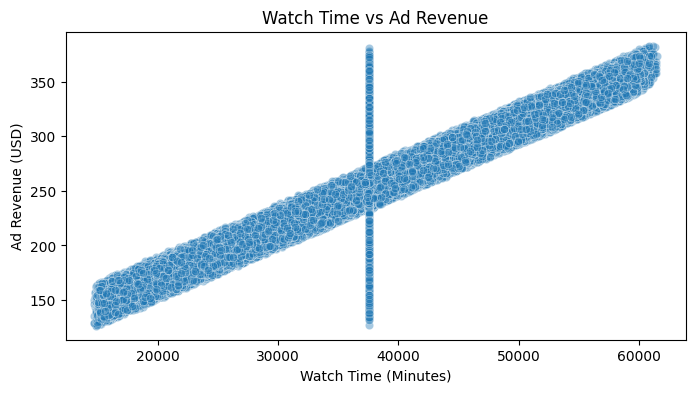

In [26]:
#Watch Time vs Ad Revenue
plt.figure(figsize=(8, 4))

sns.scatterplot(
    data=df_clean,
    x='watch_time_minutes',
    y='ad_revenue_usd',
    alpha=0.4
)

plt.title('Watch Time vs Ad Revenue')
plt.xlabel('Watch Time (Minutes)')
plt.ylabel('Ad Revenue (USD)')

plt.show()

In [27]:
#Correlation Analysis
numeric_df = df_clean.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

print(
    correlation_matrix['ad_revenue_usd']
    .sort_values(ascending=False)
)

ad_revenue_usd          1.000000
watch_time_minutes      0.964052
likes                   0.142571
views                   0.037942
comments                0.033630
subscribers             0.005065
video_length_minutes    0.000364
Name: ad_revenue_usd, dtype: float64


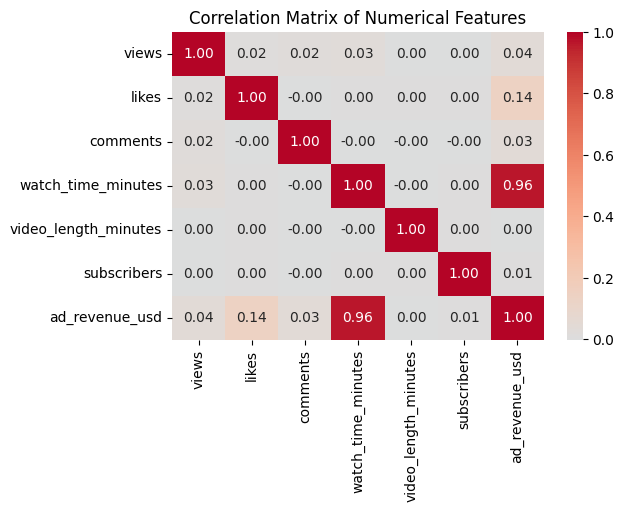

In [28]:
#Correlation Heatmap
plt.figure(figsize=(6, 4))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Features')
plt.show()

Average Ad Revenue by Category:
category
Tech             253.458882
Gaming           253.426887
Education        252.564162
Music            252.477374
Entertainment    252.397546
Lifestyle        251.936934
Name: ad_revenue_usd, dtype: float64


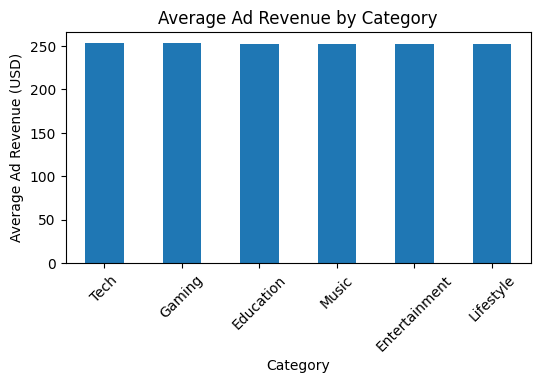

In [29]:
#Revenue by Category
category_revenue = (
    df_clean
    .groupby('category')['ad_revenue_usd']
    .mean()
    .sort_values(ascending=False)
)

print("Average Ad Revenue by Category:")
print(category_revenue)

plt.figure(figsize=(6, 3))

category_revenue.plot(kind='bar')

plt.title('Average Ad Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Average Ad Revenue (USD)')
plt.xticks(rotation=45)

plt.show()

Average Ad Revenue by Device:
device
Mobile     253.243583
Tablet     252.994347
TV         252.332093
Desktop    252.277030
Name: ad_revenue_usd, dtype: float64


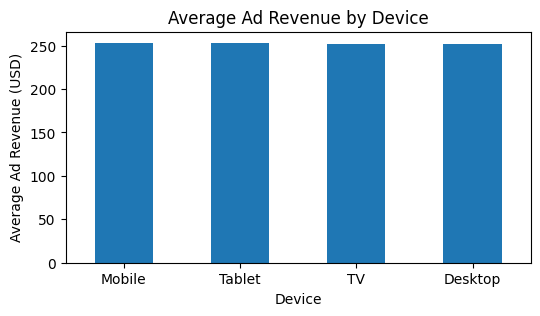

In [30]:
#Revenue by Device: whether the device used to watch the video has any relationship with revenue.
device_revenue = (
    df_clean
    .groupby('device')['ad_revenue_usd']
    .mean()
    .sort_values(ascending=False)
)

print("Average Ad Revenue by Device:")
print(device_revenue)

plt.figure(figsize=(6, 3))

device_revenue.plot(kind='bar')

plt.title('Average Ad Revenue by Device')
plt.xlabel('Device')
plt.ylabel('Average Ad Revenue (USD)')
plt.xticks(rotation=0)

plt.show()

Average Ad Revenue by Country:
country
US    253.178831
CA    252.834975
DE    252.749160
UK    252.555923
IN    252.493557
AU    252.461385
Name: ad_revenue_usd, dtype: float64


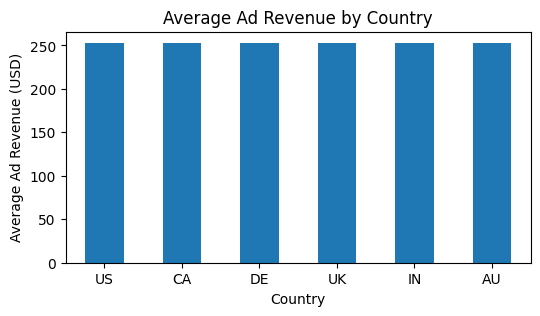

In [31]:
#Revenue by Country: whether the country has any noticeable difference in average revenue
country_revenue = (
    df_clean
    .groupby('country')['ad_revenue_usd']
    .mean()
    .sort_values(ascending=False)
)

print("Average Ad Revenue by Country:")
print(country_revenue)

plt.figure(figsize=(6, 3))

country_revenue.plot(kind='bar')

plt.title('Average Ad Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Average Ad Revenue (USD)')
plt.xticks(rotation=0)

plt.show()

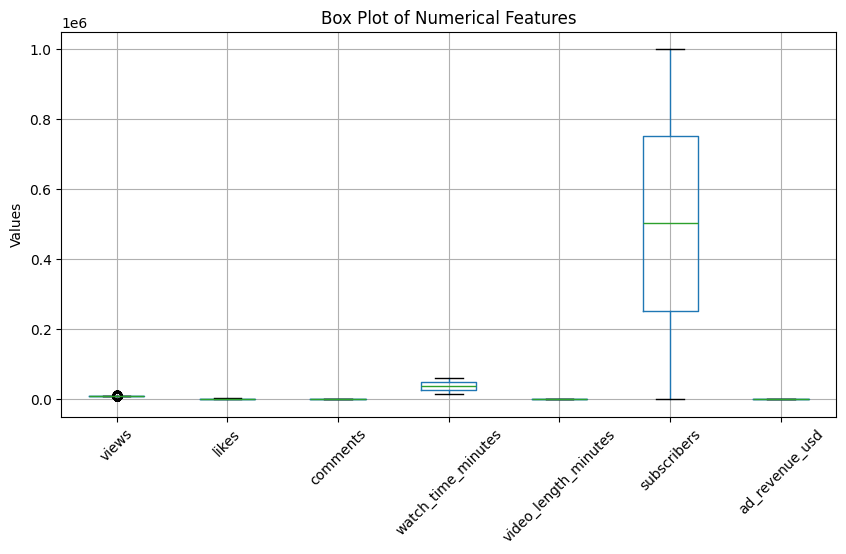

In [32]:
#Outlier Detection
numerical_columns = [
    'views',
    'likes',
    'comments',
    'watch_time_minutes',
    'video_length_minutes',
    'subscribers',
    'ad_revenue_usd'
]

plt.figure(figsize=(10, 5))

df_clean[numerical_columns].boxplot()

plt.title('Box Plot of Numerical Features')
plt.ylabel('Values')
plt.xticks(rotation=45)

plt.show()

In [33]:
#Outlier Detection: Better Analysis - IQR (Interquartile Range) method
numerical_columns = [
    'views',
    'likes',
    'comments',
    'watch_time_minutes',
    'video_length_minutes',
    'subscribers',
    'ad_revenue_usd'
]

outlier_summary = []

for col in numerical_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ]

    outlier_summary.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier %': (len(outliers) / len(df_clean)) * 100
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,views,9933.000000,10067.000000,9732.000000,1.026800e+04,865,0.720833
1,likes,673.000000,1524.000000,-603.500000,2.800500e+03,0,0.000000
2,comments,168.000000,381.000000,-151.500000,7.005000e+02,0,0.000000
3,watch_time_minutes,26949.914101,48209.880123,-4940.034932,8.009983e+04,0,0.000000
4,video_length_minutes,9.005928,23.026064,-12.024274,4.405627e+01,0,0.000000
5,subscribers,252641.500000,752386.250000,-496975.625000,1.502003e+06,0,0.000000
6,ad_revenue_usd,199.892158,305.613497,41.310148,4.641955e+02,0,0.000000


In [34]:
#Create Engagement Rate
df_clean['engagement_rate'] = (
    (df_clean['likes'] + df_clean['comments']) /
    df_clean['views']
)

print("Sample values:")
print(df_clean[['views', 'likes', 'comments', 'engagement_rate']].head())

print("\nEngagement Rate Statistics:")
print(df_clean['engagement_rate'].describe())

Sample values:
   views   likes  comments  engagement_rate
0   9936  1221.0     320.0         0.155093
1  10017   642.0     346.0         0.098632
2  10097  1979.0     187.0         0.214519
3  10034  1191.0     242.0         0.142814
4   9889  1858.0     477.0         0.236121

Engagement Rate Statistics:
count    120000.000000
mean          0.137410
std           0.052160
min           0.025492
25%           0.094965
50%           0.137501
75%           0.179921
max           0.249554
Name: engagement_rate, dtype: float64


In [35]:
#Create Like Rate

df_clean['like_rate'] = (
    df_clean['likes'] / df_clean['views']
)

print("Sample values:")
print(df_clean[['views', 'likes', 'like_rate']].head())

print("\nLike Rate Statistics:")
print(df_clean['like_rate'].describe())

Sample values:
   views   likes  like_rate
0   9936  1221.0   0.122886
1  10017   642.0   0.064091
2  10097  1979.0   0.195999
3  10034  1191.0   0.118696
4   9889  1858.0   0.187886

Like Rate Statistics:
count    120000.000000
mean          0.109976
std           0.050632
min           0.019914
25%           0.067348
50%           0.110189
75%           0.152482
max           0.199980
Name: like_rate, dtype: float64


In [36]:
#Create Comment Rate

df_clean['comment_rate'] = (
    df_clean['comments'] / df_clean['views']
)

print("Sample values:")
print(df_clean[['views', 'comments', 'comment_rate']].head())

print("\nComment Rate Statistics:")
print(df_clean['comment_rate'].describe())

Sample values:
   views  comments  comment_rate
0   9936     320.0      0.032206
1  10017     346.0      0.034541
2  10097     187.0      0.018520
3  10034     242.0      0.024118
4   9889     477.0      0.048235

Comment Rate Statistics:
count    120000.000000
mean          0.027434
std           0.012644
min           0.004911
25%           0.016817
50%           0.027392
75%           0.038072
max           0.049990
Name: comment_rate, dtype: float64


In [37]:
#Create Watch Time per View
df_clean['watch_time_per_view'] = (
    df_clean['watch_time_minutes'] / df_clean['views']
)

print("Sample values:")
print(
    df_clean[
        ['views', 'watch_time_minutes', 'watch_time_per_view']
    ].head()
)

print("\nWatch Time per View Statistics:")
print(df_clean['watch_time_per_view'].describe())

Sample values:
   views  watch_time_minutes  watch_time_per_view
0   9936        26497.214184             2.666789
1  10017        15209.747445             1.518393
2  10097        57332.658498             5.678187
3  10034        31334.517771             3.122834
4   9889        15665.666434             1.584151

Watch Time per View Statistics:
count    120000.000000
mean          3.754091
std           1.265414
min           1.500239
25%           2.695280
50%           3.751847
75%           4.819156
max           5.999977
Name: watch_time_per_view, dtype: float64


In [38]:
#Average Watch Time per View in Seconds

df_clean['avg_watch_time_seconds'] = (
    df_clean['watch_time_per_view'] * 60
)

print("Sample values:")
print(
    df_clean[
        ['watch_time_per_view', 'avg_watch_time_seconds']
    ].head()
)

print("\nAverage Watch Time Statistics:")
print(df_clean['avg_watch_time_seconds'].describe())

Sample values:
   watch_time_per_view  avg_watch_time_seconds
0             2.666789              160.007332
1             1.518393               91.103609
2             5.678187              340.691246
3             3.122834              187.370048
4             1.584151               95.049043

Average Watch Time Statistics:
count    120000.000000
mean        225.245449
std          75.924840
min          90.014326
25%         161.716828
50%         225.110816
75%         289.149350
max         359.998631
Name: avg_watch_time_seconds, dtype: float64


In [39]:
#Create Watch Time Ratio

df_clean['watch_time_ratio'] = (
    df_clean['avg_watch_time_seconds'] /
    (df_clean['video_length_minutes'] * 60)
)

print("Sample values:")
print(
    df_clean[
        [
            'video_length_minutes',
            'avg_watch_time_seconds',
            'watch_time_ratio'
        ]
    ].head()
)

print("\nWatch Time Ratio Statistics:")
print(df_clean['watch_time_ratio'].describe())

Sample values:
   video_length_minutes  avg_watch_time_seconds  watch_time_ratio
0              2.862137              160.007332          0.931748
1             23.738069               91.103609          0.063964
2             26.200634              340.691246          0.216719
3             11.770340              187.370048          0.265314
4              6.635854               95.049043          0.238726

Watch Time Ratio Statistics:
count    120000.000000
mean          0.362907
std           0.361467
min           0.050638
25%           0.154546
50%           0.234309
75%           0.416649
max           2.978006
Name: watch_time_ratio, dtype: float64


In [40]:
#Create Date-Based Features

df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month
df_clean['day_of_week'] = df_clean['date'].dt.dayofweek
df_clean['quarter'] = df_clean['date'].dt.quarter

print("Sample values:")
print(
    df_clean[
        ['date', 'year', 'month', 'day_of_week', 'quarter']
    ].head()
)

print("\nUnique values:")
print("Years:", sorted(df_clean['year'].unique()))
print("Months:", sorted(df_clean['month'].unique()))
print("Days of week:", sorted(df_clean['day_of_week'].unique()))
print("Quarters:", sorted(df_clean['quarter'].unique()))

Sample values:
                        date  year  month  day_of_week  quarter
0 2024-09-24 10:50:40.993199  2024      9            1        3
1 2024-09-22 10:50:40.993199  2024      9            6        3
2 2024-11-21 10:50:40.993199  2024     11            3        4
3 2025-01-28 10:50:40.993199  2025      1            1        1
4 2025-04-28 10:50:40.993199  2025      4            0        2

Unique values:
Years: [np.int32(2024), np.int32(2025)]
Months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Days of week: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]
Quarters: [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]


In [41]:
#Review Feature Engineering Results

print("Dataset shape:", df_clean.shape)

print("\nAll columns:")
print(df_clean.columns.tolist())
print("Number of columns:", len(df_clean.columns))

Dataset shape: (120000, 22)

All columns:
['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'category', 'device', 'country', 'ad_revenue_usd', 'engagement_rate', 'like_rate', 'comment_rate', 'watch_time_per_view', 'avg_watch_time_seconds', 'watch_time_ratio', 'year', 'month', 'day_of_week', 'quarter']
Number of columns: 22


In [42]:
#Feature Analysis: Correlation of Engineered Features with Ad Revenue

engineered_features = [
    'engagement_rate',
    'like_rate',
    'comment_rate',
    'watch_time_per_view',
    'avg_watch_time_seconds',
    'watch_time_ratio',
    'year',
    'month',
    'day_of_week',
    'quarter'
]

engineered_correlations = (
    df_clean[engineered_features + ['ad_revenue_usd']]
    .corr()['ad_revenue_usd']
    .drop('ad_revenue_usd')
    .sort_values(ascending=False)
)

print("Correlation of Engineered Features with Ad Revenue:")
print(engineered_correlations)

Correlation of Engineered Features with Ad Revenue:
watch_time_per_view       0.963199
avg_watch_time_seconds    0.963199
watch_time_ratio          0.327907
engagement_rate           0.145552
like_rate                 0.141744
comment_rate              0.032833
year                      0.001053
month                     0.000872
quarter                   0.000278
day_of_week              -0.001010
Name: ad_revenue_usd, dtype: float64


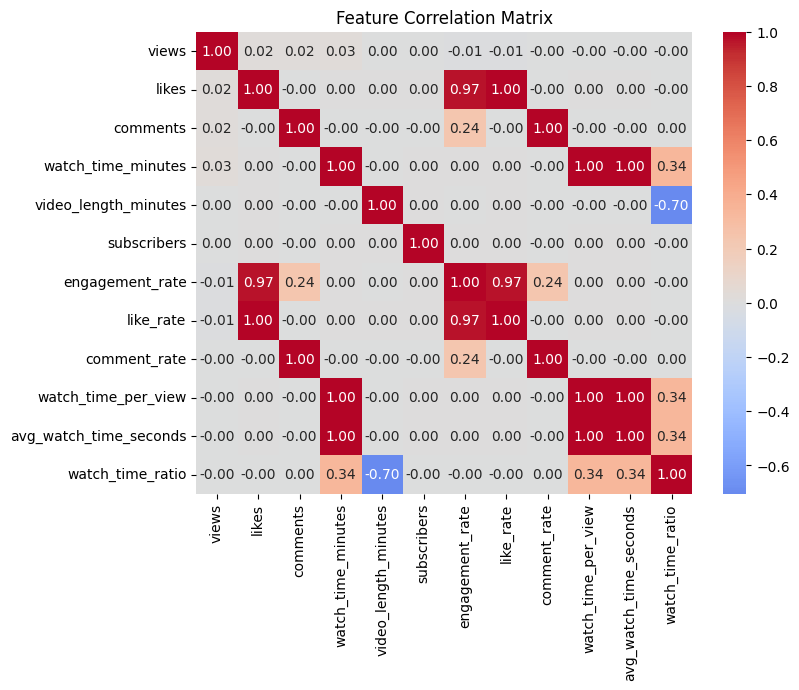

In [43]:
#Check Correlation Between Model Features

model_features = [
    'views',
    'likes',
    'comments',
    'watch_time_minutes',
    'video_length_minutes',
    'subscribers',
    'engagement_rate',
    'like_rate',
    'comment_rate',
    'watch_time_per_view',
    'avg_watch_time_seconds',
    'watch_time_ratio'
]

feature_correlation = df_clean[model_features].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    feature_correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Feature Correlation Matrix')
plt.show()

In [44]:
#Remove Redundant Features

redundant_features = [
    'watch_time_per_view',
    'like_rate',
    'comment_rate'
]

df_model = df_clean.drop(columns=redundant_features).copy()

print("Original shape:", df_clean.shape)
print("Model dataset shape:", df_model.shape)

print("\nRemoved features:")
print(redundant_features)

print("\nRemaining columns:")
print(df_model.columns.tolist())

Original shape: (120000, 22)
Model dataset shape: (120000, 19)

Removed features:
['watch_time_per_view', 'like_rate', 'comment_rate']

Remaining columns:
['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'category', 'device', 'country', 'ad_revenue_usd', 'engagement_rate', 'avg_watch_time_seconds', 'watch_time_ratio', 'year', 'month', 'day_of_week', 'quarter']


In [45]:
#Define Features (X) and Target (y)

target = 'ad_revenue_usd'

features = [
    'views',
    'likes',
    'comments',
    'watch_time_minutes',
    'video_length_minutes',
    'subscribers',
    'engagement_rate',
    'avg_watch_time_seconds',
    'watch_time_ratio',
    'year',
    'month',
    'day_of_week',
    'quarter',
    'category',
    'device',
    'country'
]

# Input features
X = df_model[features].copy()

# Target variable
y = df_model[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

print("\ny name:", y.name)

X shape: (120000, 16)
y shape: (120000,)

X columns:
['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'engagement_rate', 'avg_watch_time_seconds', 'watch_time_ratio', 'year', 'month', 'day_of_week', 'quarter', 'category', 'device', 'country']

y name: ad_revenue_usd


In [46]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (96000, 16)
X_test shape: (24000, 16)
y_train shape: (96000,)
y_test shape: (24000,)


In [47]:
#Identify Numerical and Categorical Features

numerical_features = [
    'views',
    'likes',
    'comments',
    'watch_time_minutes',
    'video_length_minutes',
    'subscribers',
    'engagement_rate',
    'avg_watch_time_seconds',
    'watch_time_ratio',
    'year',
    'month',
    'day_of_week',
    'quarter'
]

categorical_features = [
    'category',
    'device',
    'country'
]

print("Number of numerical features:", len(numerical_features))
print("Numerical features:")
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Categorical features:")
print(categorical_features)

Number of numerical features: 13
Numerical features:
['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'engagement_rate', 'avg_watch_time_seconds', 'watch_time_ratio', 'year', 'month', 'day_of_week', 'quarter']

Number of categorical features: 3
Categorical features:
['category', 'device', 'country']


In [48]:
#Build Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical preprocessing
numerical_transformer = StandardScaler()

# Categorical preprocessing
categorical_transformer = OneHotEncoder(
    handle_unknown='ignore'
)

# Combine both transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")
print(preprocessor)

Preprocessing pipeline created successfully.
ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['views', 'likes', 'comments',
                                  'watch_time_minutes', 'video_length_minutes',
                                  'subscribers', 'engagement_rate',
                                  'avg_watch_time_seconds', 'watch_time_ratio',
                                  'year', 'month', 'day_of_week', 'quarter']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['category', 'device', 'country'])])


In [49]:
#Apply Preprocessing

# Fit the preprocessor only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Original X_train shape:", X_train.shape)
print("Original X_test shape:", X_test.shape)

print("\nProcessed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

print("\nPreprocessing completed successfully.")

Original X_train shape: (96000, 16)
Original X_test shape: (24000, 16)

Processed X_train shape: (96000, 29)
Processed X_test shape: (24000, 29)

Preprocessing completed successfully.


In [50]:
#Model Building
#Linear Regression

from sklearn.linear_model import LinearRegression

# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_processed, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [51]:
#Generate Linear Regression Predictions

y_pred_linear = linear_model.predict(X_test_processed)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_linear))

print("\nFirst 10 actual values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted values:")
print(y_pred_linear[:10])

Predictions generated successfully.
Number of predictions: 24000

First 10 actual values:
[352.85352072 341.98378848 204.58688315 176.83567028 270.84283909
 287.47745471 259.93837372 261.08931703 275.03554405 307.00635101]

First 10 predicted values:
[352.80429492 342.2267789  204.43971664 176.3624454  270.8962278
 287.73799744 260.03511216 261.44173512 275.14743558 307.30740308]


In [52]:
#Ridge Regression

from sklearn.linear_model import Ridge

# Create Ridge Regression model
ridge_model = Ridge(alpha=1.0)

# Train the model
ridge_model.fit(X_train_processed, y_train)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


In [53]:
#Generate Ridge Regression Predictions

y_pred_ridge = ridge_model.predict(X_test_processed)

print("Ridge predictions generated successfully.")
print("Number of predictions:", len(y_pred_ridge))

print("\nFirst 10 actual values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted values:")
print(y_pred_ridge[:10])

Ridge predictions generated successfully.
Number of predictions: 24000

First 10 actual values:
[352.85352072 341.98378848 204.58688315 176.83567028 270.84283909
 287.47745471 259.93837372 261.08931703 275.03554405 307.00635101]

First 10 predicted values:
[352.81760588 342.13148607 204.39988018 176.33704253 270.89490719
 287.72745782 260.05869932 261.44195361 275.15061777 307.26812217]


In [54]:
#Lasso Regression

from sklearn.linear_model import Lasso

# Create Lasso Regression model
lasso_model = Lasso(alpha=0.001, max_iter=10000)

# Train the model
lasso_model.fit(X_train_processed, y_train)

print("Lasso Regression model trained successfully.")

Lasso Regression model trained successfully.


In [55]:
#Generate Lasso Regression Predictions

y_pred_lasso = lasso_model.predict(X_test_processed)

print("Lasso predictions generated successfully.")
print("Number of predictions:", len(y_pred_lasso))

print("\nFirst 10 actual values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted values:")
print(y_pred_lasso[:10])

Lasso predictions generated successfully.
Number of predictions: 24000

First 10 actual values:
[352.85352072 341.98378848 204.58688315 176.83567028 270.84283909
 287.47745471 259.93837372 261.08931703 275.03554405 307.00635101]

First 10 predicted values:
[352.79960241 342.19281588 204.38147364 176.46372918 270.93595008
 287.699431   260.19070588 261.46499554 275.26063573 307.359401  ]


In [56]:
#Random Forest Regression

from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_processed, y_train)

print("Random Forest Regression model trained successfully.")

Random Forest Regression model trained successfully.


In [57]:
#Generate Random Forest Predictions

y_pred_rf = random_forest_model.predict(X_test_processed)

print("Random Forest predictions generated successfully.")
print("Number of predictions:", len(y_pred_rf))

print("\nFirst 10 actual values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted values:")
print(y_pred_rf[:10])

Random Forest predictions generated successfully.
Number of predictions: 24000

First 10 actual values:
[352.85352072 341.98378848 204.58688315 176.83567028 270.84283909
 287.47745471 259.93837372 261.08931703 275.03554405 307.00635101]

First 10 predicted values:
[352.67229402 342.06296932 204.58131049 176.68836407 270.58548589
 287.43866712 259.01774942 260.526514   274.86064369 306.63766135]


In [58]:
#Gradient Boosting Regression

from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(X_train_processed, y_train)

print("Gradient Boosting Regression model trained successfully.")

Gradient Boosting Regression model trained successfully.


In [59]:
#Generate Gradient Boosting Predictions

y_pred_gb = gradient_boosting_model.predict(X_test_processed)

print("Gradient Boosting predictions generated successfully.")
print("Number of predictions:", len(y_pred_gb))

print("\nFirst 10 actual values:")
print(y_test.head(10).values)

print("\nFirst 10 predicted values:")
print(y_pred_gb[:10])

Gradient Boosting predictions generated successfully.
Number of predictions: 24000

First 10 actual values:
[352.85352072 341.98378848 204.58688315 176.83567028 270.84283909
 287.47745471 259.93837372 261.08931703 275.03554405 307.00635101]

First 10 predicted values:
[352.83897943 341.6445774  204.08247216 176.99560422 270.71087789
 288.04001369 258.97916764 261.44630329 274.85065792 307.29203246]


In [60]:
# Calculate Evaluation Metrics all all the above models

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# Store all model predictions
predictions = {
    'Linear Regression': y_pred_linear,
    'Ridge Regression': y_pred_ridge,
    'Lasso Regression': y_pred_lasso,
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb
}

# Calculate metrics for each model
results = []

for model_name, y_pred in predictions.items():
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        'Model': model_name,
        'R² Score': r2,
        'RMSE': rmse,
        'MAE': mae
    })

# Create comparison DataFrame
results_df = pd.DataFrame(results)

# Sort by R² Score (highest first)
results_df = results_df.sort_values(
    by='R² Score',
    ascending=False
).reset_index(drop=True)

print("Model Evaluation Results:")
display(results_df)

Model Evaluation Results:


,Model,R² Score,RMSE,MAE
0,Lasso Regression,0.952578,13.479422,3.112963
1,Ridge Regression,0.952571,13.480408,3.123246
2,Linear Regression,0.952571,13.480500,3.122464
3,Gradient Boosting,0.952230,13.528815,3.621010
4,Random Forest,0.951483,13.634156,3.522039


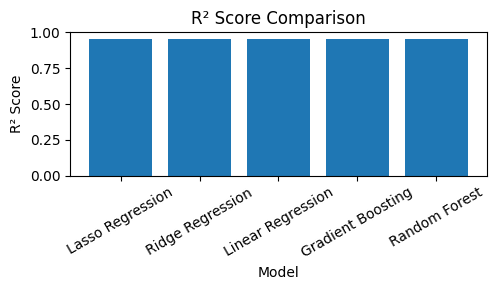

In [61]:
#Model Comparison & Best Model Selection
# Model Performance Visualization

import matplotlib.pyplot as plt

# R² Score
plt.figure(figsize=(5, 3))
plt.bar(results_df['Model'], results_df['R² Score'])
plt.title('R² Score Comparison')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

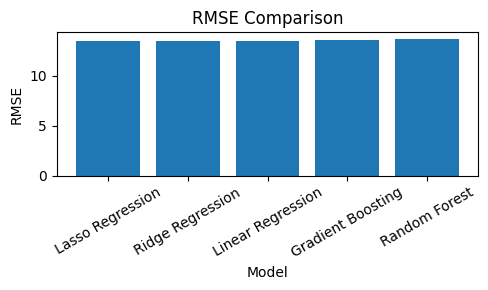

In [62]:
# RMSE Comparison

plt.figure(figsize=(5, 3))
plt.bar(results_df['Model'], results_df['RMSE'])
plt.title('RMSE Comparison')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

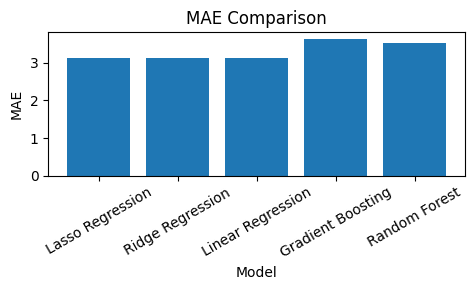

In [63]:
# MAE Comparison

plt.figure(figsize=(5, 3))
plt.bar(results_df['Model'], results_df['MAE'])
plt.title('MAE Comparison')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [64]:
# Select Best Model

best_model_name = results_df.iloc[0]['Model']

print("Best Model:", best_model_name)

Best Model: Lasso Regression


In [65]:
# Store Final Model

final_model = lasso_model

print("Final model selected successfully.")
print("Model:", type(final_model).__name__)

Final model selected successfully.
Model: Lasso


In [66]:
#  Get Processed Feature Names

# Define the numerical and categorical columns again
numerical_features = [
    'views',
    'likes',
    'comments',
    'watch_time_minutes',
    'video_length_minutes',
    'subscribers',
    'engagement_rate',
    'avg_watch_time_seconds',
    'watch_time_ratio',
    'year',
    'month',
    'day_of_week',
    'quarter'
]

categorical_features = (
    preprocessor
    .named_transformers_['cat']
    .get_feature_names_out([
        'category',
        'device',
        'country'
    ])
)

# Combine numerical + encoded categorical features
feature_names = numerical_features + list(categorical_features)

print("Number of processed features:", len(feature_names))

print("\nProcessed Feature Names:")
for i, feature in enumerate(feature_names):
    print(i, feature)

Number of processed features: 29

Processed Feature Names:
0 views
1 likes
2 comments
3 watch_time_minutes
4 video_length_minutes
5 subscribers
6 engagement_rate
7 avg_watch_time_seconds
8 watch_time_ratio
9 year
10 month
11 day_of_week
12 quarter
13 category_Education
14 category_Entertainment
15 category_Gaming
16 category_Lifestyle
17 category_Music
18 category_Tech
19 device_Desktop
20 device_Mobile
21 device_TV
22 device_Tablet
23 country_AU
24 country_CA
25 country_DE
26 country_IN
27 country_UK
28 country_US


In [67]:
# Analyze Lasso Coefficients

# Get Lasso coefficients
coefficients = final_model.coef_

# Create a DataFrame
coefficient_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Add absolute coefficient for ranking
coefficient_df['Absolute_Coefficient'] = (
    coefficient_df['Coefficient'].abs()
)

# Sort by absolute coefficient
coefficient_df = coefficient_df.sort_values(
    by='Absolute_Coefficient',
    ascending=False
).reset_index(drop=True)

print("Lasso Coefficient Analysis:")
display(coefficient_df)

Lasso Coefficient Analysis:


,Feature,Coefficient,Absolute_Coefficient
0,watch_time_minutes,59.604036,59.604036
1,likes,8.651744,8.651744
2,comments,2.126020,2.126020
3,views,0.661075,0.661075
4,month,0.193669,0.193669
5,device_TV,-0.147328,0.147328
6,quarter,-0.105086,0.105086
7,year,0.098686,0.098686
8,country_IN,0.087020,0.087020
9,device_Desktop,0.079638,0.079638


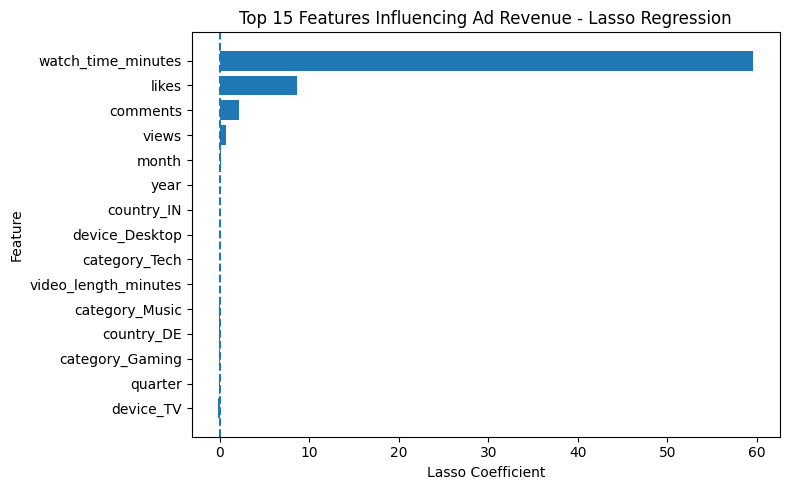

In [68]:
#  Visualize Top 15 Lasso Features

import matplotlib.pyplot as plt

# Select top 15 features based on absolute coefficient
top_features = coefficient_df.head(15).copy()

# Sort for better visualization
top_features = top_features.sort_values(
    by='Coefficient',
    ascending=True
)

# Create the chart
plt.figure(figsize=(8, 5))

plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.axvline(x=0, linestyle='--')

plt.title('Top 15 Features Influencing Ad Revenue - Lasso Regression')
plt.xlabel('Lasso Coefficient')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [69]:
#  Business Insights

print("Business Insights from the Lasso Regression Model")
print("=" * 60)

print("""
1. Watch time is the most important factor influencing ad revenue.
   The Lasso coefficient for watch_time_minutes is approximately 59.60.

2. Likes are the second most influential feature, with a positive
   coefficient of approximately 8.65.

3. Comments also have a positive influence on ad revenue, although
   their effect is smaller than likes and watch time.

4. Views have a positive but relatively small influence compared
   with watch time.

5. Some categorical and date-related features have relatively
   small effects on predicted ad revenue.

6. Lasso reduced some feature coefficients to zero, including
   engagement_rate, category_Entertainment, and device_Tablet.
   This indicates that these features provide limited additional
   predictive value in the final model.

7. Overall, the model suggests that viewer watch time and audience
   engagement are more important for predicting ad revenue than
   simply the number of views.
""")

Business Insights from the Lasso Regression Model

1. Watch time is the most important factor influencing ad revenue.
   The Lasso coefficient for watch_time_minutes is approximately 59.60.

2. Likes are the second most influential feature, with a positive
   coefficient of approximately 8.65.

3. Comments also have a positive influence on ad revenue, although
   their effect is smaller than likes and watch time.

4. Views have a positive but relatively small influence compared
   with watch time.

5. Some categorical and date-related features have relatively
   small effects on predicted ad revenue.

6. Lasso reduced some feature coefficients to zero, including
   engagement_rate, category_Entertainment, and device_Tablet.
   This indicates that these features provide limited additional
   predictive value in the final model.

7. Overall, the model suggests that viewer watch time and audience
   engagement are more important for predicting ad revenue than
   simply the number of views

In [70]:
# Step 9.1: Create Final Model Pipeline

from sklearn.pipeline import Pipeline

# Combine preprocessing and Lasso model
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_model)
])

print("Final model pipeline created successfully!")
print(final_pipeline)

Final model pipeline created successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['views', 'likes', 'comments',
                                                   'watch_time_minutes',
                                                   'video_length_minutes',
                                                   'subscribers',
                                                   'engagement_rate',
                                                   'avg_watch_time_seconds',
                                                   'watch_time_ratio', 'year',
                                                   'month', 'day_of_week',
                                                   'quarter']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                          

In [71]:
# Step 9.2: Test the Final Pipeline

# Generate predictions using the complete pipeline
final_predictions = final_pipeline.predict(X_test)

print("Final pipeline predictions generated successfully!")
print("Number of predictions:", len(final_predictions))

print("\nFirst 10 actual values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 predicted values:")
print(final_predictions[:10])

Final pipeline predictions generated successfully!
Number of predictions: 24000

First 10 actual values:
[352.85352072 341.98378848 204.58688315 176.83567028 270.84283909
 287.47745471 259.93837372 261.08931703 275.03554405 307.00635101]

First 10 predicted values:
[352.79960241 342.19281588 204.38147364 176.46372918 270.93595008
 287.699431   260.19070588 261.46499554 275.26063573 307.359401  ]


In [72]:
# Step 9.3: Save Final Model Pipeline

import joblib

# Save the complete pipeline
model_filename = "content_monetization_lasso_pipeline.pkl"

joblib.dump(final_pipeline, model_filename)

print("Final model pipeline saved successfully!")
print("File name:", model_filename)

Final model pipeline saved successfully!
File name: content_monetization_lasso_pipeline.pkl


In [73]:
# Step 9.4: Verify Saved Model

import joblib

# Load the saved pipeline
loaded_model = joblib.load("content_monetization_lasso_pipeline.pkl")
#loaded_model = joblib.load("/content/content_monetization_lasso_pipeline.pkl")

print("Saved model loaded successfully!")
print("\nLoaded model:")
print(loaded_model)

# Test prediction
test_predictions = loaded_model.predict(X_test)

print("\nPrediction test successful!")
print("Number of predictions:", len(test_predictions))

print("\nFirst 5 predictions:")
print(test_predictions[:5])

Saved model loaded successfully!

Loaded model:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['views', 'likes', 'comments',
                                                   'watch_time_minutes',
                                                   'video_length_minutes',
                                                   'subscribers',
                                                   'engagement_rate',
                                                   'avg_watch_time_seconds',
                                                   'watch_time_ratio', 'year',
                                                   'month', 'day_of_week',
                                                   'quarter']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                     

In [152]:
# Create the project folder
import os

project_folder = "/content/Content_Monetization_Modeler"

os.makedirs(project_folder, exist_ok=True)

print("Project folder created successfully!")
print(project_folder)

Project folder created successfully!
/content/Content_Monetization_Modeler


In [153]:
# Copy your saved model into the project folder
import shutil
import os

source_model = "/content/content_monetization_lasso_pipeline.pkl"
destination_model = "/content/Content_Monetization_Modeler/content_monetization_lasso_pipeline.pkl"

shutil.copy(source_model, destination_model)

print("Model copied successfully!")

Model copied successfully!


In [154]:
# Verify the project structure
print(os.listdir(project_folder))

['content_monetization_lasso_pipeline.pkl']


In [155]:
!pip install -q streamlit

In [156]:
import streamlit

print("Streamlit version:", streamlit.__version__)

Streamlit version: 1.61.1


In [157]:
import streamlit as st
import joblib
import pandas as pd

# Load the saved Lasso pipeline
model_path = "/content/Content_Monetization_Modeler/content_monetization_lasso_pipeline.pkl"

model = joblib.load(model_path)

In [158]:
# Step 10.3(a) - Streamlit Input + Feature Engineering

app_code = '''
import streamlit as st
import joblib
import pandas as pd
import datetime

# --------------------------------------------------
# Load Saved Lasso Pipeline
# --------------------------------------------------

model_path = "/content/Content_Monetization_Modeler/content_monetization_lasso_pipeline.pkl"

model = joblib.load(model_path)


# --------------------------------------------------
# Page Configuration
# --------------------------------------------------

st.set_page_config(
    page_title="Content Monetization Modeler",
    page_icon="📊",
    layout="wide"
)


# --------------------------------------------------
# Title
# --------------------------------------------------

st.title("📊 Content Monetization Modeler")

st.write(
    "Predict estimated YouTube ad revenue based on video performance "
    "and contextual information."
)

st.divider()


# --------------------------------------------------
# User Input Section
# --------------------------------------------------

st.header("Enter Video Details")

col1, col2 = st.columns(2)


# --------------------------------------------------
# Column 1
# --------------------------------------------------

with col1:

    views = st.number_input(
        "Views",
        min_value=1,
        value=10000,
        step=100
    )

    likes = st.number_input(
        "Likes",
        min_value=0.0,
        value=1100.0,
        step=10.0
    )

    comments = st.number_input(
        "Comments",
        min_value=0.0,
        value=274.0,
        step=10.0
    )

    watch_time_minutes = st.number_input(
        "Watch Time (minutes)",
        min_value=0.0,
        value=37500.0,
        step=100.0
    )

    video_length_minutes = st.number_input(
        "Video Length (minutes)",
        min_value=0.1,
        value=16.0,
        step=0.5
    )

    upload_date = st.date_input(
        "Video Upload Date",
        value=datetime.date(2025, 1, 1)
    )


# --------------------------------------------------
# Column 2
# --------------------------------------------------

with col2:

    subscribers = st.number_input(
        "Subscribers",
        min_value=0,
        value=500000,
        step=1000
    )

    category = st.selectbox(
        "Category",
        [
            "Education",
            "Music",
            "Tech",
            "Entertainment",
            "Gaming",
            "Lifestyle"
        ]
    )

    device = st.selectbox(
        "Device",
        [
            "TV",
            "Mobile",
            "Desktop",
            "Tablet"
        ]
    )

    country = st.selectbox(
        "Country",
        [
            "CA",
            "DE",
            "IN",
            "AU",
            "UK",
            "US"
        ]
    )


# --------------------------------------------------
# Feature Engineering
# --------------------------------------------------

st.divider()

st.header("Automatically Calculated Features")


# Engagement Rate
engagement_rate = (likes + comments) / views


# Like Rate
like_rate = likes / views


# Comment Rate
comment_rate = comments / views


# Watch Time per View
watch_time_per_view = watch_time_minutes / views


# Average Watch Time in Seconds
avg_watch_time_seconds = watch_time_per_view * 60


# Watch Time Ratio
watch_time_ratio = (
    avg_watch_time_seconds /
    (video_length_minutes * 60)
)


# --------------------------------------------------
# Date-Based Features
# --------------------------------------------------

year = upload_date.year

month = upload_date.month

# Monday = 0, Sunday = 6
day_of_week = upload_date.weekday()

# Quarter calculation
quarter = (month - 1) // 3 + 1


# --------------------------------------------------
# Display Engineered Features
# --------------------------------------------------

feature_col1, feature_col2 = st.columns(2)


with feature_col1:

    st.metric(
        "Engagement Rate",
        f"{engagement_rate:.4f}"
    )

    st.metric(
        "Like Rate",
        f"{like_rate:.4f}"
    )

    st.metric(
        "Comment Rate",
        f"{comment_rate:.4f}"
    )

    st.metric(
        "Watch Time per View",
        f"{watch_time_per_view:.4f}"
    )


with feature_col2:

    st.metric(
        "Average Watch Time (seconds)",
        f"{avg_watch_time_seconds:.2f}"
    )

    st.metric(
        "Watch Time Ratio",
        f"{watch_time_ratio:.4f}"
    )

    st.metric(
        "Year",
        year
    )

    st.metric(
        "Quarter",
        quarter
    )


# --------------------------------------------------
# Create Model Input DataFrame
# --------------------------------------------------

st.divider()

if st.button("Predict Revenue", type="primary"):

    input_data = pd.DataFrame({

        'views': [views],

        'likes': [likes],

        'comments': [comments],

        'watch_time_minutes': [watch_time_minutes],

        'video_length_minutes': [video_length_minutes],

        'subscribers': [subscribers],

        'engagement_rate': [engagement_rate],

        'avg_watch_time_seconds': [avg_watch_time_seconds],

        'watch_time_ratio': [watch_time_ratio],

        'year': [year],

        'month': [month],

        'day_of_week': [day_of_week],

        'quarter': [quarter],

        'category': [category],

        'device': [device],

        'country': [country]
    })


    # Display model input
    st.subheader("Model Input")

    st.dataframe(input_data)

    # Generate prediction
    prediction = model.predict(input_data)[0]

    # Display prediction
    st.subheader("Estimated Ad Revenue")

    st.success(
    f"Estimated Ad Revenue: ${prediction:,.2f}"
    )
'''


# --------------------------------------------------
# Save app.py
# --------------------------------------------------

app_path = "/content/Content_Monetization_Modeler/app.py"

with open(app_path, "w") as f:

    f.write(app_code)


print("Step 10.3(a) completed successfully!")
print("app.py saved at:", app_path)

Step 10.3(a) completed successfully!
app.py saved at: /content/Content_Monetization_Modeler/app.py


In [159]:
# Step 10.7(a): Create pages folder

import os

pages_path = "/content/Content_Monetization_Modeler/pages"

os.makedirs(pages_path, exist_ok=True)

print("Pages folder created successfully!")
print("Location:", pages_path)

Pages folder created successfully!
Location: /content/Content_Monetization_Modeler/pages


In [160]:
# Step 10.7(c): Create visualization data

import pandas as pd
import os

# Model comparison results
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "R2": [
        0.9525,
        0.9525,
        0.9526,
        0.9523,
        0.9524
    ]
})

# Lasso feature coefficients from our trained model
lasso_coefficients = pd.DataFrame({
    "Feature": [
        "watch_time_minutes",
        "likes",
        "comments",
        "views",
        "month",
        "device_TV",
        "quarter",
        "year",
        "country_IN",
        "device_Desktop"
    ],
    "Coefficient": [
        59.604036,
        8.651744,
        2.126020,
        0.661075,
        0.193669,
        -0.147328,
        -0.105086,
        0.098686,
        0.087020,
        0.079638
    ]
})

# Save the data
model_results.to_csv(
    "/content/Content_Monetization_Modeler/model_results.csv",
    index=False
)

lasso_coefficients.to_csv(
    "/content/Content_Monetization_Modeler/lasso_coefficients.csv",
    index=False
)

print("Visualization data created successfully!")
print("Model results:")
display(model_results)

print("\nLasso coefficients:")
display(lasso_coefficients)

Visualization data created successfully!
Model results:


,Model,R2
0,Linear Regression,0.9525
1,Ridge Regression,0.9525
2,Lasso Regression,0.9526
3,Random Forest,0.9523
4,Gradient Boosting,0.9524



Lasso coefficients:


,Feature,Coefficient
0,watch_time_minutes,59.604036
1,likes,8.651744
2,comments,2.126020
3,views,0.661075
4,month,0.193669
5,device_TV,-0.147328
6,quarter,-0.105086
7,year,0.098686
8,country_IN,0.087020
9,device_Desktop,0.079638


In [161]:
# Step 10.7(b): Create Business Insights page

business_insights_code = '''
import streamlit as st
import pandas as pd

# Page configuration
st.set_page_config(
    page_title="Business Insights",
    page_icon="💼",
    layout="wide"
)

# --------------------------------------------------
# Title
# --------------------------------------------------

st.title("💼 Business Insights")

st.write(
    "Business insights and visual analytics from the "
    "Content Monetization Modeler."
)

st.divider()

# --------------------------------------------------
# Key Model Finding
# --------------------------------------------------

st.header("🔍 Key Model Finding")

st.success(
    "Watch Time is the strongest feature influencing "
    "predicted YouTube ad revenue."
)

st.write(
    "Based on the Lasso Regression model, "
    "watch_time_minutes had the highest coefficient "
    "among the model features."
)

st.divider()

# --------------------------------------------------
# Top Features
# --------------------------------------------------

st.header("📈 Top Revenue Influencing Features")

feature_data = pd.DataFrame({
    "Feature": [
        "Watch Time",
        "Likes",
        "Comments",
        "Views"
    ],
    "Coefficient": [
        59.604036,
        8.651744,
        2.126020,
        0.661075
    ]
})

st.bar_chart(
    feature_data.set_index("Feature")
)

st.divider()

# --------------------------------------------------
# Business Insights
# --------------------------------------------------

st.header("💡 Business Insights")

st.markdown("""
### ⏱️ 1. Increase Watch Time

Watch time is the strongest feature in the Lasso model.
Improving viewer retention can increase monetization potential.

### ❤️ 2. Improve Audience Engagement

Likes and comments have positive coefficients.
Encouraging audience interaction can strengthen engagement.

### 👀 3. Increase Video Reach

Increasing views provides more opportunities for ad exposure.

### 🎯 4. Improve Viewer Retention

Engaging introductions, useful content and good storytelling
can encourage viewers to watch for longer.
""")

st.divider()

# --------------------------------------------------
# Business Recommendations
# --------------------------------------------------

st.header("🎯 Business Recommendations")

recommendations = [
    "Improve the first 30 seconds of videos.",
    "Create engaging content to increase watch time.",
    "Encourage viewers to like and comment.",
    "Optimize titles and thumbnails to increase views.",
    "Monitor audience retention and identify viewer drop-off.",
    "Use audience engagement data to improve future content."
]

for recommendation in recommendations:
    st.write("✅ " + recommendation)

st.divider()

st.caption(
    "Content Monetization Modeler | Social Media Analytics"
)
'''

business_insights_path = (
    "/content/Content_Monetization_Modeler/pages/Business_Insights.py"
)

with open(business_insights_path, "w") as f:
    f.write(business_insights_code)

print("Step 10.7(b) completed successfully!")
print("Business Insights page created at:")
print(business_insights_path)

Step 10.7(b) completed successfully!
Business Insights page created at:
/content/Content_Monetization_Modeler/pages/Business_Insights.py


In [162]:
# Step 10.7(c): Add Model Performance Visualization

business_insights_path = (
    "/content/Content_Monetization_Modeler/pages/Business_Insights.py"
)

business_insights_code = '''
import streamlit as st
import pandas as pd

# Page configuration
st.set_page_config(
    page_title="Business Insights",
    page_icon="💼",
    layout="wide"
)

# --------------------------------------------------
# Title
# --------------------------------------------------

st.title("💼 Business Insights")

st.write(
    "Business insights and visual analytics from the "
    "Content Monetization Modeler."
)

st.divider()

# --------------------------------------------------
# Model Performance Comparison
# --------------------------------------------------

st.header("📊 Model Performance Comparison")

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "R2": [
        0.9525,
        0.9525,
        0.9526,
        0.9523,
        0.9524
    ]
})

st.bar_chart(
    model_results.set_index("Model")
)

st.write(
    "The Lasso Regression model achieved the highest R² score "
    "among the evaluated models."
)

st.success(
    "Lasso Regression was selected as the final model with an R² score of 0.9526."
)

st.divider()

# --------------------------------------------------
# Key Model Finding
# --------------------------------------------------

st.header("🔍 Key Model Finding")

st.success(
    "Watch Time is the strongest feature influencing "
    "predicted YouTube ad revenue."
)

st.write(
    "The Lasso Regression model identified "
    "watch_time_minutes as the most influential feature, "
    "with a coefficient of approximately 59.60."
)

st.divider()

# --------------------------------------------------
# Top Revenue Influencing Features
# --------------------------------------------------

st.header("📈 Top Revenue Influencing Features")

feature_data = pd.DataFrame({
    "Feature": [
        "Watch Time",
        "Likes",
        "Comments",
        "Views"
    ],
    "Coefficient": [
        59.604036,
        8.651744,
        2.126020,
        0.661075
    ]
})

st.bar_chart(
    feature_data.set_index("Feature")
)

st.divider()

# --------------------------------------------------
# Business Insights
# --------------------------------------------------

st.header("💡 Business Insights")

st.markdown("""
### ⏱️ 1. Increase Watch Time

Watch time is the strongest feature in the Lasso model.
Improving viewer retention can increase monetization potential.

### ❤️ 2. Improve Audience Engagement

Likes and comments have positive coefficients.
Encouraging audience interaction can strengthen engagement.

### 👀 3. Increase Video Reach

Increasing views provides more opportunities for ad exposure.

### 🎯 4. Improve Viewer Retention

Engaging introductions, useful content and good storytelling
can encourage viewers to watch for longer.
""")

st.divider()

# --------------------------------------------------
# Business Recommendations
# --------------------------------------------------

st.header("🎯 Business Recommendations")

recommendations = [
    "Improve the first 30 seconds of videos.",
    "Create engaging content to increase watch time.",
    "Encourage viewers to like and comment.",
    "Optimize titles and thumbnails to increase views.",
    "Monitor audience retention and identify viewer drop-off.",
    "Use audience engagement data to improve future content."
]

for recommendation in recommendations:
    st.write("✅ " + recommendation)

st.divider()

st.caption(
    "Content Monetization Modeler | Social Media Analytics"
)
'''

with open(business_insights_path, "w") as f:
    f.write(business_insights_code)

print("Step 10.7(c) completed successfully!")
print("Business Insights page updated successfully!")

Step 10.7(c) completed successfully!
Business Insights page updated successfully!


In [169]:
# Step 10.7(f-1): Regenerate Lasso predictions

import joblib
import pandas as pd

# Load the saved final Lasso pipeline
model_path = "/content/Content_Monetization_Modeler/content_monetization_lasso_pipeline.pkl"

lasso_pipeline = joblib.load(model_path)

# Generate predictions using the test dataset
lasso_predictions = lasso_pipeline.predict(X_test)

print("Lasso predictions regenerated successfully!")
print("Number of predictions:", len(lasso_predictions))

print("\nFirst 10 predictions:")
print(lasso_predictions[:10])

Lasso predictions regenerated successfully!
Number of predictions: 24000

First 10 predictions:
[352.79960241 342.19281588 204.38147364 176.46372918 270.93595008
 287.699431   260.19070588 261.46499554 275.26063573 307.359401  ]


In [170]:
# Step 10.7(f-2): Save Actual vs Predicted Revenue Data

actual_predicted = pd.DataFrame({
    "Actual Revenue": y_test.values,
    "Predicted Revenue": lasso_predictions
})

actual_predicted_path = (
    "/content/Content_Monetization_Modeler/actual_vs_predicted.csv"
)

actual_predicted.to_csv(
    actual_predicted_path,
    index=False
)

print("Actual vs Predicted data saved successfully!")
print("File:", actual_predicted_path)
print("Number of records:", len(actual_predicted))

Actual vs Predicted data saved successfully!
File: /content/Content_Monetization_Modeler/actual_vs_predicted.csv
Number of records: 24000


In [171]:
# Step 10.7(f-3): Add Actual vs Predicted Revenue Visualization

business_insights_path = (
    "/content/Content_Monetization_Modeler/pages/Business_Insights.py"
)

business_insights_code = '''
import streamlit as st
import pandas as pd

# Page configuration
st.set_page_config(
    page_title="Business Insights",
    page_icon="💼",
    layout="wide"
)

st.title("💼 Business Insights")

st.write(
    "Business insights and visual analytics from the "
    "Content Monetization Modeler."
)

st.divider()

# --------------------------------------------------
# Model Performance Comparison
# --------------------------------------------------

st.header("📊 Model Performance Comparison")

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "R2": [
        0.9525,
        0.9525,
        0.9526,
        0.9523,
        0.9524
    ]
})

st.bar_chart(
    model_results.set_index("Model")
)

st.success(
    "Lasso Regression was selected as the final model "
    "with an R² score of 0.9526."
)

st.divider()

# --------------------------------------------------
# Top Revenue Influencing Features
# --------------------------------------------------

st.header("📈 Top Revenue Influencing Features")

feature_data = pd.DataFrame({
    "Feature": [
        "Watch Time",
        "Likes",
        "Comments",
        "Views"
    ],
    "Coefficient": [
        59.604036,
        8.651744,
        2.126020,
        0.661075
    ]
})

st.bar_chart(
    feature_data.set_index("Feature")
)

st.write(
    "Watch Time has the strongest positive coefficient "
    "in the Lasso model."
)

st.divider()

# --------------------------------------------------
# Actual vs Predicted Revenue
# --------------------------------------------------

st.header("🎯 Actual vs Predicted Revenue")

data_path = (
    "/content/Content_Monetization_Modeler/"
    "actual_vs_predicted.csv"
)

actual_predicted = pd.read_csv(data_path)

st.write(
    "This visualization compares the actual revenue values "
    "with the revenue predicted by the final Lasso model."
)

# Display a sample of the 24,000 predictions
chart_data = actual_predicted.head(100).copy()

chart_data.index = range(1, len(chart_data) + 1)

st.line_chart(
    chart_data[
        ["Actual Revenue", "Predicted Revenue"]
    ]
)

st.metric(
    "Test Predictions",
    f"{len(actual_predicted):,}"
)

st.info(
    "The predicted values closely follow the actual revenue "
    "values, indicating strong model performance."
)

st.divider()

# --------------------------------------------------
# Key Model Finding
# --------------------------------------------------

st.header("🔍 Key Model Finding")

st.success(
    "Watch Time is the strongest feature influencing "
    "predicted YouTube ad revenue."
)

st.write(
    "The Lasso Regression model identified "
    "watch_time_minutes as the most influential feature, "
    "with a coefficient of approximately 59.60."
)

st.divider()

# --------------------------------------------------
# Business Insights
# --------------------------------------------------

st.header("💡 Business Insights")

st.markdown("""
### ⏱️ 1. Increase Watch Time

Watch time is the strongest feature in the Lasso model.
Improving viewer retention can increase monetization potential.

### ❤️ 2. Improve Audience Engagement

Likes and comments have positive coefficients.
Encouraging audience interaction can strengthen engagement.

### 👀 3. Increase Video Reach

Increasing views provides more opportunities for ad exposure.

### 🎯 4. Improve Viewer Retention

Engaging introductions, useful content and good storytelling
can encourage viewers to watch for longer.
""")

st.divider()

# --------------------------------------------------
# Business Recommendations
# --------------------------------------------------

st.header("🎯 Business Recommendations")

recommendations = [
    "Improve the first 30 seconds of videos.",
    "Create engaging content to increase watch time.",
    "Encourage viewers to like and comment.",
    "Optimize titles and thumbnails to increase views.",
    "Monitor audience retention and identify viewer drop-off.",
    "Use audience engagement data to improve future content."
]

for recommendation in recommendations:
    st.write("✅ " + recommendation)

st.divider()

st.caption(
    "Content Monetization Modeler | Social Media Analytics"
)
'''

with open(business_insights_path, "w") as f:
    f.write(business_insights_code)

print("Step 10.7(f-3) completed successfully!")
print("Business Insights page updated with Actual vs Predicted visualization.")

Step 10.7(f-3) completed successfully!
Business Insights page updated with Actual vs Predicted visualization.


In [172]:
import os

print(os.listdir("/content/Content_Monetization_Modeler"))

['model_results.csv', 'app.py', 'lasso_coefficients.csv', 'content_monetization_lasso_pipeline.pkl', 'pages', 'actual_vs_predicted.csv']


In [173]:
!streamlit run /content/Content_Monetization_Modeler/app.py &>/content/streamlit.log &

In [174]:
!wget -q -O- ipv4.icanhazip.com

34.106.230.95


In [176]:
!wget -q -O /content/cloudflared \
    https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64

!chmod +x /content/cloudflared

In [177]:
!nohup /content/cloudflared tunnel --url http://localhost:8501 > /content/cloudflared.log 2>&1 &

In [178]:
!cat /content/cloudflared.log

2026-08-16T15:46:41Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-16T15:46:41Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-16T15:46:44Z INF +--------------------------------------------------------------------------------------------+
2026-08-16T15:46:44Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-16T15:46:44Z INF |  https://pitch-living-dialog-comparisons.trycloudflare

In [120]:
# Final project file check

import os

project_path = "/content/Content_Monetization_Modeler"

print("Project files:")
for root, dirs, files in os.walk(project_path):
    level = root.replace(project_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

Project files:
Content_Monetization_Modeler/
    model_results.csv
    app.py
    lasso_coefficients.csv
    content_monetization_lasso_pipeline.pkl
    actual_vs_predicted.csv
    pages/
        Business_Insights.py


In [121]:
# Verify project files

import os
import pandas as pd

project_path = "/content/Content_Monetization_Modeler"

# Check model file
model_file = os.path.join(
    project_path,
    "content_monetization_lasso_pipeline.pkl"
)

print("Model file exists:", os.path.exists(model_file))

# Check Actual vs Predicted data
actual_predicted_file = os.path.join(
    project_path,
    "actual_vs_predicted.csv"
)

actual_predicted = pd.read_csv(actual_predicted_file)

print("Actual vs Predicted file exists:",
      os.path.exists(actual_predicted_file))

print("Actual vs Predicted rows:",
      len(actual_predicted))

print("\nColumns:")
print(actual_predicted.columns.tolist())

# Check model results
model_results_file = os.path.join(
    project_path,
    "model_results.csv"
)

model_results = pd.read_csv(model_results_file)

print("\nModel Results file exists:",
      os.path.exists(model_results_file))

print("Model Results:")
display(model_results)

print("\nStep 10.8(b) completed successfully!")

Model file exists: True
Actual vs Predicted file exists: True
Actual vs Predicted rows: 24000

Columns:
['Actual Revenue', 'Predicted Revenue']

Model Results file exists: True
Model Results:


,Model,R2
0,Linear Regression,0.9525
1,Ridge Regression,0.9525
2,Lasso Regression,0.9526
3,Random Forest,0.9523
4,Gradient Boosting,0.9524



Step 10.8(b) completed successfully!


In [122]:
# Verify Streamlit application files

import os

project_path = "/content/Content_Monetization_Modeler"

app_file = os.path.join(project_path, "app.py")
business_page = os.path.join(
    project_path,
    "pages",
    "Business_Insights.py"
)

print("Main Streamlit app exists:", os.path.exists(app_file))
print("Business Insights page exists:", os.path.exists(business_page))

# Check that the main app contains Streamlit code
with open(app_file, "r") as f:
    app_content = f.read()

print("Main app contains Streamlit:", "import streamlit" in app_content)

# Check Business Insights page
with open(business_page, "r") as f:
    business_content = f.read()

print(
    "Business Insights contains Streamlit:",
    "import streamlit" in business_content
)

print(
    "Business Insights contains Actual vs Predicted:",
    "Actual vs Predicted Revenue" in business_content
)

print(
    "Business Insights contains Model Performance:",
    "Model Performance Comparison" in business_content
)

print("\nStep 10.8(c) completed successfully!")

Main Streamlit app exists: True
Business Insights page exists: True
Main app contains Streamlit: True
Business Insights contains Streamlit: True
Business Insights contains Actual vs Predicted: True
Business Insights contains Model Performance: True

Step 10.8(c) completed successfully!


In [123]:
# Final Lasso prediction test

import joblib
import pandas as pd

project_path = "/content/Content_Monetization_Modeler"

# Load final saved pipeline
model_path = (
    f"{project_path}/content_monetization_lasso_pipeline.pkl"
)

final_model = joblib.load(model_path)

# Sample user input
test_input = pd.DataFrame({
    "views": [10000],
    "likes": [1100],
    "comments": [274],
    "watch_time_minutes": [37500],
    "video_length_minutes": [16],
    "subscribers": [500000],
    "engagement_rate": [(1100 + 274) / 10000],
    "avg_watch_time_seconds": [(37500 / 10000) * 60],
    "watch_time_ratio": [
        ((37500 / 10000) * 60) / (16 * 60)
    ],
    "year": [2024],
    "month": [1],
    "day_of_week": [0],
    "quarter": [1],
    "category": ["Education"],
    "device": ["Mobile"],
    "country": ["IN"]
})

# Generate prediction
prediction = final_model.predict(test_input)

print("Final prediction test successful!")
print("Number of predictions:", len(prediction))
print("Predicted Revenue:", prediction[0])

Final prediction test successful!
Number of predictions: 1
Predicted Revenue: 252.31695300223


In [124]:
# Final project readiness check

import os

project_path = "/content/Content_Monetization_Modeler"

required_files = [
    "app.py",
    "content_monetization_lasso_pipeline.pkl",
    "actual_vs_predicted.csv",
    "model_results.csv",
    "lasso_coefficients.csv",
    "pages/Business_Insights.py"
]

print("FINAL PROJECT READINESS CHECK")
print("=" * 50)

all_files_present = True

for file in required_files:
    file_path = os.path.join(project_path, file)
    exists = os.path.exists(file_path)

    print(
        f"{'✅' if exists else '❌'} {file}"
    )

    if not exists:
        all_files_present = False

print("=" * 50)

if all_files_present:
    print("🎉 ALL REQUIRED PROJECT FILES ARE PRESENT!")
    print("Project is ready for final submission.")
else:
    print("⚠️ Some required files are missing.")

FINAL PROJECT READINESS CHECK
✅ app.py
✅ content_monetization_lasso_pipeline.pkl
✅ actual_vs_predicted.csv
✅ model_results.csv
✅ lasso_coefficients.csv
✅ pages/Business_Insights.py
🎉 ALL REQUIRED PROJECT FILES ARE PRESENT!
Project is ready for final submission.
